# Required packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from itertools import product
import warnings

In [3]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.diagnostic import kstest_normal
from typing import Union
from tqdm.notebook import tqdm

# 9.1) Examining the SARIMAX model

## 9.1.1) Exploring the exogenous variables of US macroeconomics

In [4]:
macro_data = sm.datasets.macrodata.load_pandas()

In [5]:
macro_data.keys()

dict_keys(['data', 'names', 'raw_data'])

In [6]:
macro_econ = macro_data['data']

In [7]:
macro_econ.info()

<class 'pandas.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      203 non-null    float64
 1   quarter   203 non-null    float64
 2   realgdp   203 non-null    float64
 3   realcons  203 non-null    float64
 4   realinv   203 non-null    float64
 5   realgovt  203 non-null    float64
 6   realdpi   203 non-null    float64
 7   cpi       203 non-null    float64
 8   m1        203 non-null    float64
 9   tbilrate  203 non-null    float64
 10  unemp     203 non-null    float64
 11  pop       203 non-null    float64
 12  infl      203 non-null    float64
 13  realint   203 non-null    float64
dtypes: float64(14)
memory usage: 22.3 KB


In [8]:
macro_econ.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


In [9]:
macro_econ.to_csv('data/macroeconomics_us.csv')

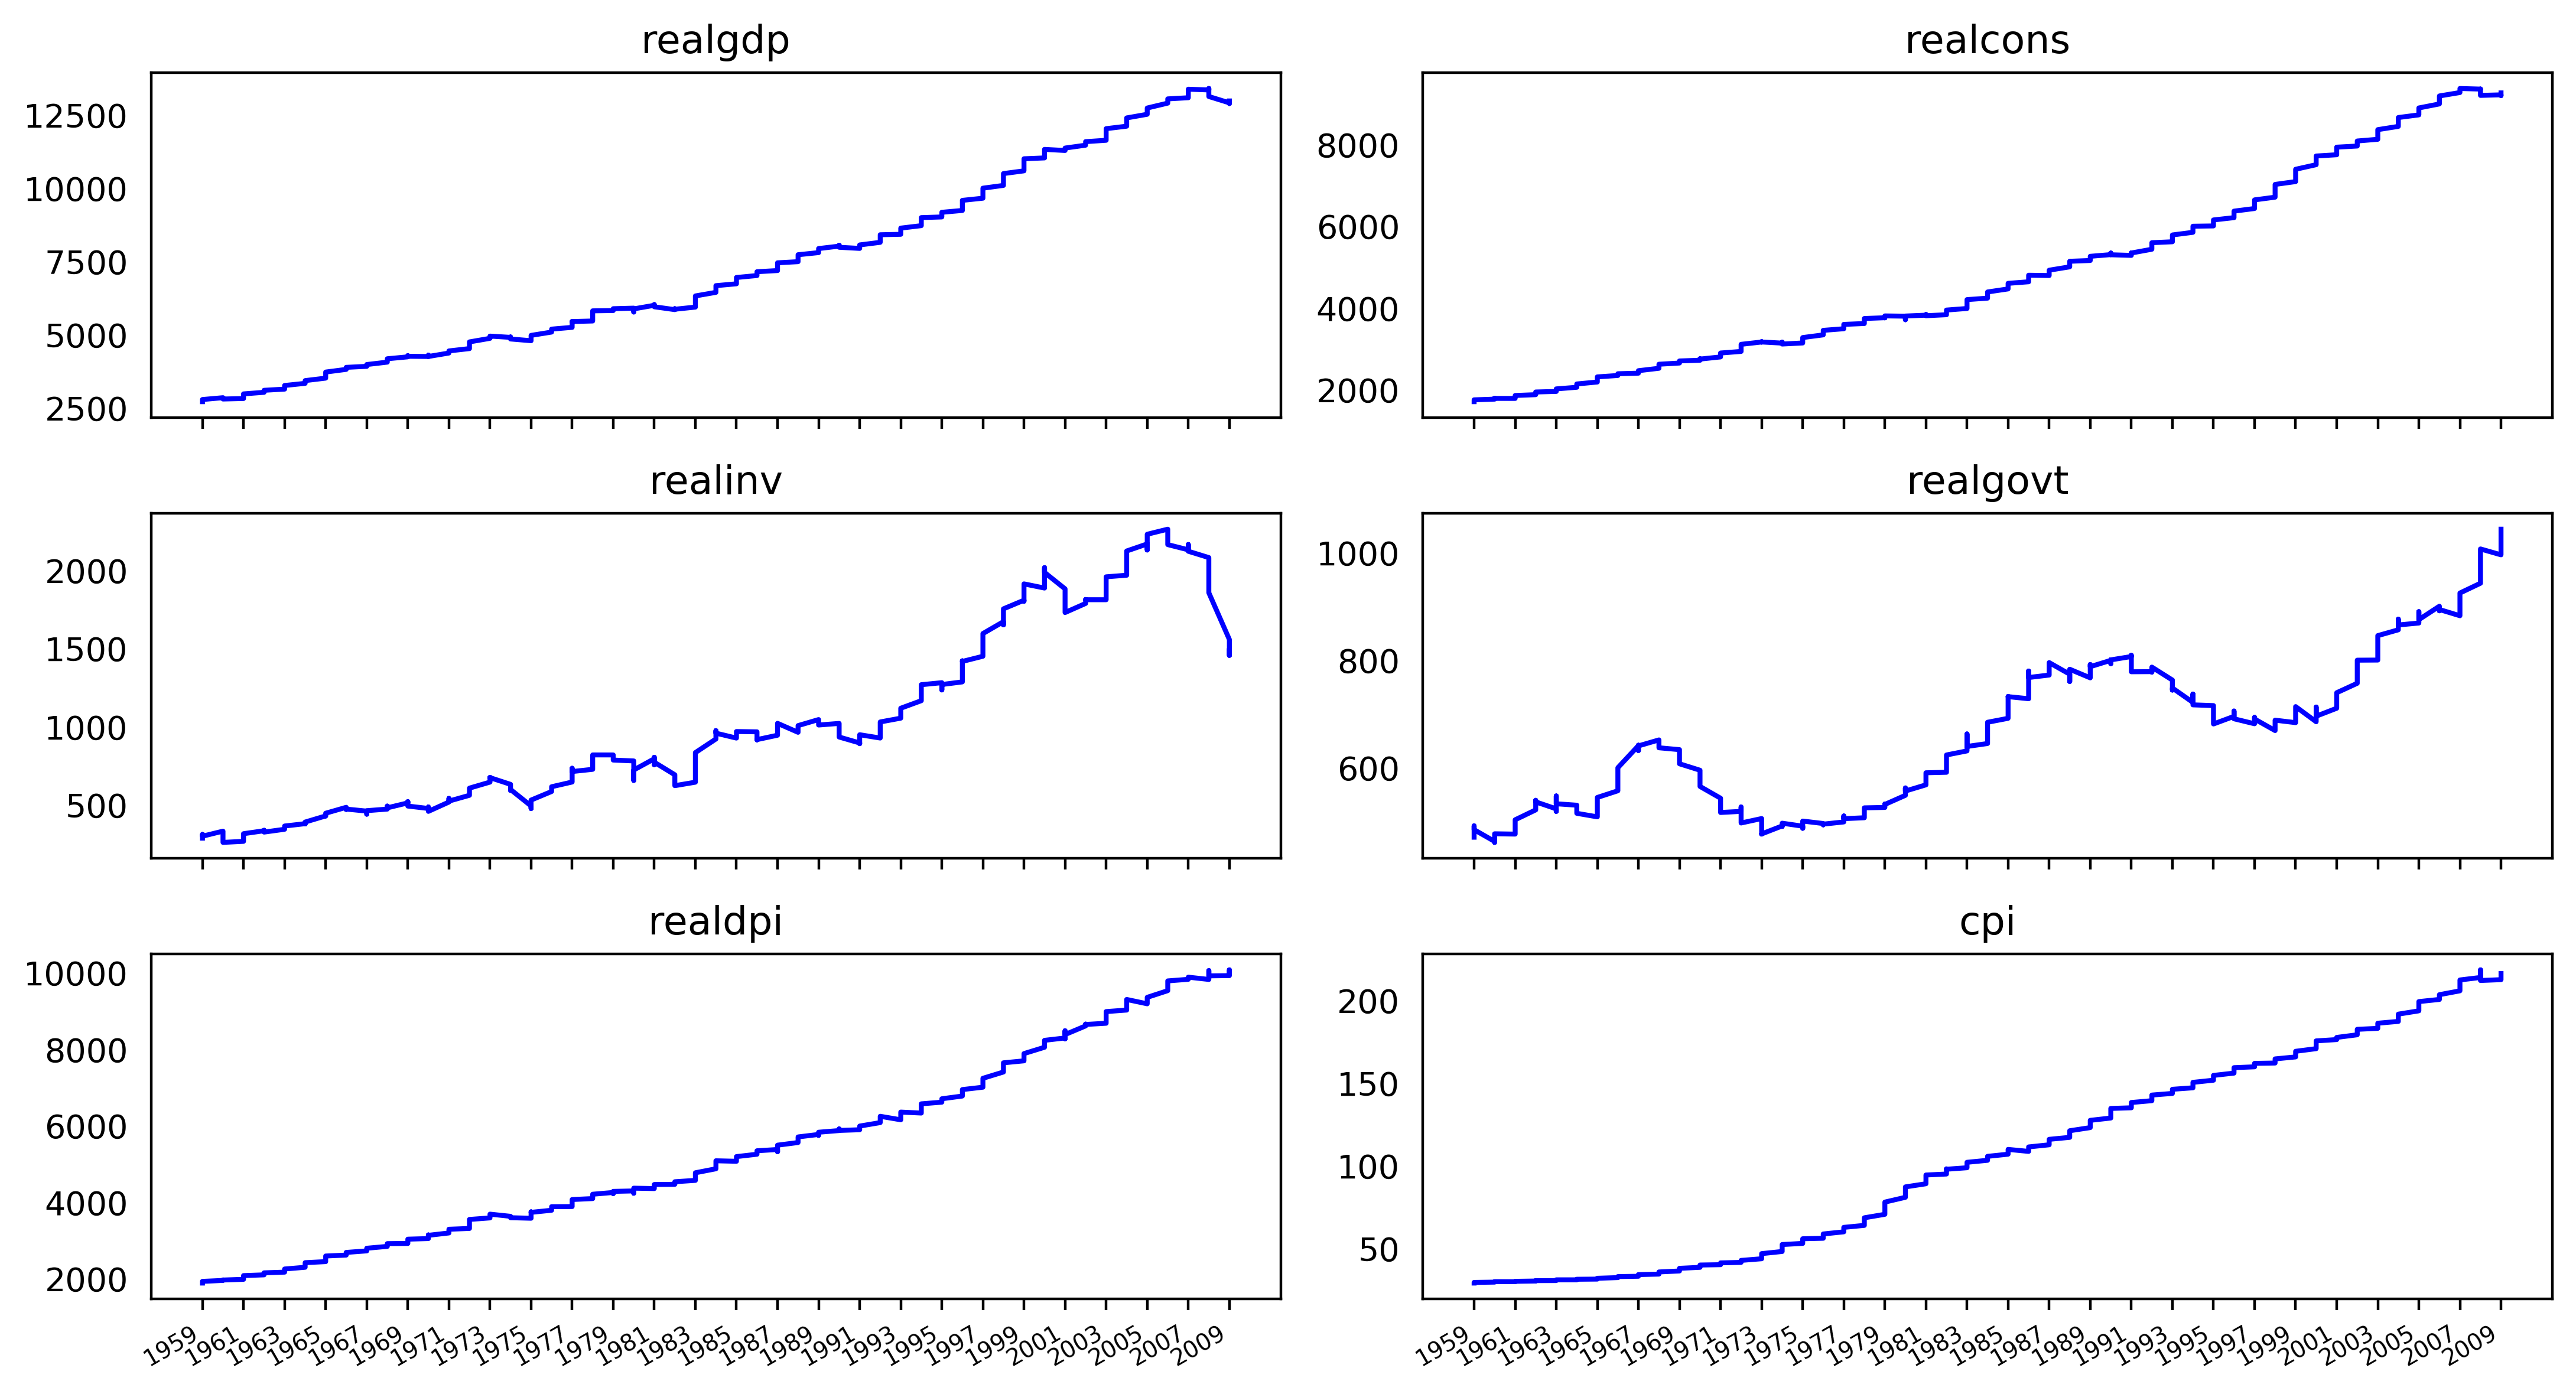

In [10]:
fig, ax = plt.subplots(nrows=3, ncols=2, dpi=400, figsize=(11, 6), sharex=True)

col = 2
for i, j in product(range(3), range(2)):
    ax[i, j].plot(macro_econ.iloc[:, 0], macro_econ.iloc[:, col], 'b-')
    ax[i, j]. set_title(macro_econ.columns[col])
    #ax[i, j].xaxis.set_ticks_position('none') # remove tick lines
    ax[i, j].yaxis.set_ticks_position('none') # remove tick lines
    ax[i, j].set_xticks(
        macro_econ.iloc[::8, 0]
    )
    ax[i, j].tick_params(axis='x',labelsize=7)
    col += 1
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

# 9.2) Forecasting the real GDP using the SARIMAX model

In [11]:
type(macro_econ)

pandas.DataFrame

In [12]:
target = macro_econ['realgdp']
exog = macro_econ[['realcons', 'realinv', 'realgovt', 'realdpi', 'cpi']]

In [13]:
adfuller(target)

(np.float64(1.7504627967647128),
 np.float64(0.9982455372335032),
 12,
 190,
 {'1%': np.float64(-3.4652439354133255),
  '5%': np.float64(-2.8768752281673717),
  '10%': np.float64(-2.574944653739612)},
 np.float64(2034.517123668382))

In [14]:
adfuller(np.diff(target))

(np.float64(-6.305695561658104),
 np.float64(3.327882187668259e-08),
 1,
 200,
 {'1%': np.float64(-3.463476079125),
  '5%': np.float64(-2.876102355),
  '10%': np.float64(-2.574532225)},
 np.float64(2024.992358126391))

## Optimization function

In [15]:
def optimize_SARIMAX(
    endog: Union[list, tuple, pd.Series],
    exog: Union[pd.Series, list],
    order_list: Union[tuple, list],
) -> pd.DataFrame:
    """
    Find the best SARIMAX model using AIC.

    Params:
    --------
    endog: Union[list, tuple, pd.Series]
        target variable
    exog: Union[pd.Series, list]
        exogenous variables
    order_list: Union[tuple, list]
        a list or a tuple with of tuples (or lists) with p, d, q, P, D, Q, m

    Returns:
    ---------
    Returns a pd.DataFrame object with p, d, q, P, D, Q, AIC.
    """
    results = []

    for order in tqdm(orderlist):
        try:
            with warnings.catch_warnings():
                 warnings.simplefilter("ignore")
                 model = SARIMAX(
                    endog, exog,
                    order=order[:3],
                    seasonal_order=order[3:],
                    simple_differencing=False
                 ).fit(disp=False)
            results.append([*order, model.aic])
        except:
            continue


    result_df = pd.DataFrame(results, columns=('p', 'd', 'q', 'P', 'D', 'Q', 'm', 'AIC'))
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)

    return result_df

## Choosing the best model using AIC

In [16]:
orderlist = list(product(
    range(4), [1], range(4), range(4), [0], range(4), [4]
))

In [17]:
orderlist[:3]

[(0, 1, 0, 0, 0, 0, 4), (0, 1, 0, 0, 0, 1, 4), (0, 1, 0, 0, 0, 2, 4)]

In [18]:
target_train = target.loc[:200]
exog_train = exog.loc[:200, :]

In [19]:
df_aic = optimize_SARIMAX(
    target_train, exog_train,
    order_list=orderlist
)

  0%|          | 0/256 [00:00<?, ?it/s]

In [20]:
df_aic.head(n=15)

,p,d,q,P,D,Q,m,AIC
0,2,1,3,0,0,0,4,1755.799944
1,3,1,3,0,0,0,4,1757.050268
2,2,1,3,1,0,0,4,1759.095904
3,3,1,3,0,0,1,4,1759.136296
4,3,1,3,1,0,0,4,1759.178100
5,2,1,3,0,0,1,4,1759.677788
6,3,1,2,0,0,0,4,1759.904152
7,3,1,3,2,0,2,4,1760.217892
8,3,1,3,0,0,2,4,1760.515990
9,3,1,3,2,0,0,4,1760.532316


In [21]:
df_aic.shape

(256, 8)

In [22]:
df_aic.info()

<class 'pandas.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   p       256 non-null    int64  
 1   d       256 non-null    int64  
 2   q       256 non-null    int64  
 3   P       256 non-null    int64  
 4   D       256 non-null    int64  
 5   Q       256 non-null    int64  
 6   m       256 non-null    int64  
 7   AIC     256 non-null    float64
dtypes: float64(1), int64(7)
memory usage: 16.1 KB


## Fitting the model

In [23]:
best_model = SARIMAX(
    target_train, exog_train,
    order=(2, 1, 3),
    seasonal_order=(0, 0, 0, 4),
    simple_differencing=False
).fit(disp=False)

/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [24]:
print(best_model.summary())

                               SARIMAX Results                                
Dep. Variable:                realgdp   No. Observations:                  201
Model:               SARIMAX(2, 1, 3)   Log Likelihood                -866.900
Date:                Thu, 04 Jun 2026   AIC                           1755.800
Time:                        08:05:47   BIC                           1792.081
Sample:                             0   HQIC                          1770.483
                                - 201                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
realcons       0.9861      0.045     22.053      0.000       0.898       1.074
realinv        0.9707      0.025     38.508      0.000       0.921       1.020
realgovt       0.6956      0.123      5.637      0.0

## Goodness of fit

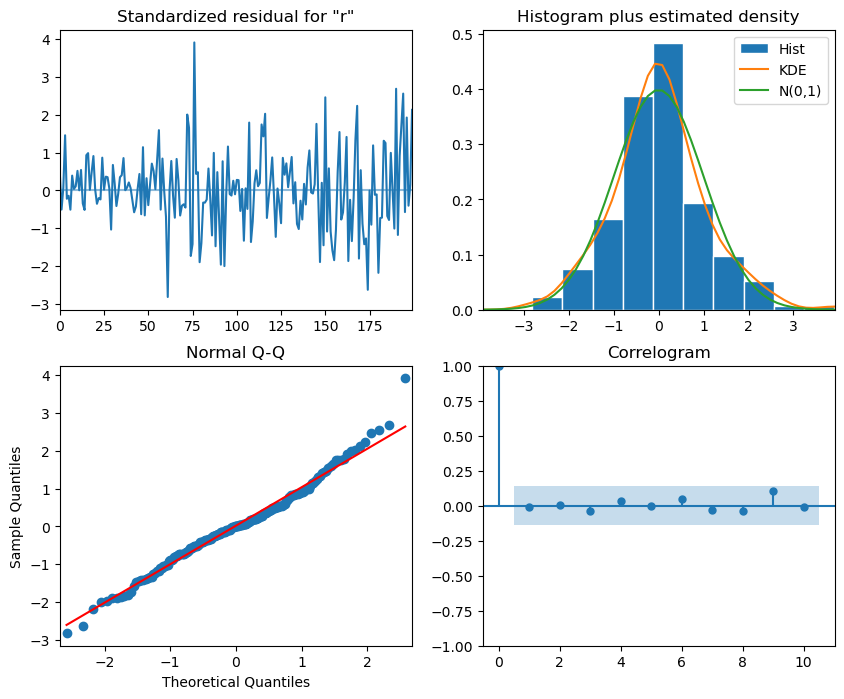

In [25]:
best_model.plot_diagnostics(figsize=(10, 8));

In [26]:
resid = best_model.resid
df_lb = acorr_ljungbox(resid, lags=20)

In [27]:
df_lb

,lb_stat,lb_pvalue
1,0.030453,0.861466
2,0.096670,0.952814
3,0.177286,0.981170
4,1.272349,0.866049
5,1.289781,0.935980
6,1.386344,0.966684
7,1.610796,0.978224
8,1.613810,0.990653
9,2.375273,0.984052
10,2.375435,0.992569


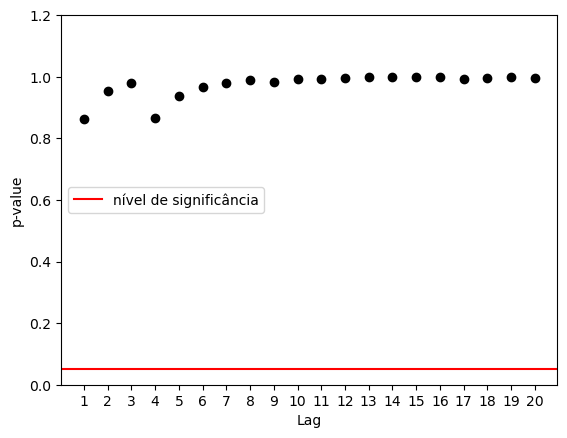

In [28]:
fig, ax = plt.subplots()
ax.plot(df_lb.lb_pvalue, 'ko')
ax.set_ylim([0, 1.2])
ax.set_xticks(df_lb.index)
ax.axhline(y=0.05, color='red', label='nível de significância')
ax.legend(loc='center left')
ax.set_xlabel('Lag')
ax.set_ylabel('p-value')
plt.show()

In [29]:
kstest_normal(resid)

(np.float64(0.12471465921179337), np.float64(0.0009999999999998899))

## Rolling forecast

In [30]:
def recursive_forecast(
    endog: Union[pd.Series, list], exog: Union[pd.Series, list],
    train_len: int, horizon: int, window:int,
    method: str, 
    order: Union[tuple, list] = (2, 1, 3), seasonal_order: Union[tuple, list] = (0, 0, 0, 4)
) -> list:
    """
    Recursive forecast to evaluate the forecasting methods.

    Params:
    --------
    endog: Union[pd.Series, list]
        Endogenous time series.
    exog: Union[pd.Series, list]
        Exogenous time series.
    train_len: int
        Sample size used to train.
    horizon: int
        Horizon to forecast.
    window:
        Window of forecast.
    order: Union[tuple, list]
        ARIMA order of SARIMAX.
    seasonal_order: Union[tuple, list]
        Seasonal order of SARIMAX.

    Returns:
    ---------
        A list with horizon elements.
    """
    total_len = train_len + horizon

    if method == 'last':
        pred = []

        for i in tqdm(range(train_len, total_len, window), desc='Last value'):
            last_value = endog[:i].iloc[-1]
            pred.extend(last_value for _ in range(window))
        return pred
    elif method == 'sarimax':
        pred = []
        
        for i in tqdm(range(train_len, total_len, window), desc='SARIMAX'):
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model = SARIMAX(
                    endog[:i], exog[:i], order = order, seasonal_order=seasonal_order,
                    simple_differencing=False
                ).fit(disp=False)
                predictions = model.\
                    get_prediction(exog=exog).predicted_mean
            pred.extend(predictions[-window:])
        return pred
            
    else:
        raise Exception("'method' must be 'last' or 'sarimax'.")

In [31]:
target_train = target[:196]
target_test = target[196:]
WINDOW = 1
TRAIN_LEN = len(target_train)
HORIZON = len(target_test)

In [32]:
recursive_forecast(
    target, exog, TRAIN_LEN, HORIZON, WINDOW, 'sarimax'
)

SARIMAX:   0%|          | 0/7 [00:00<?, ?it/s]

[13341.347435365227,
 13373.018830754536,
 13370.760129880333,
 13342.919330495226,
 13134.30535994575,
 12886.95671221883,
 12870.15918385101]

In [33]:
df_pred = pd.DataFrame({
    'observed': target_test,
    'last_value': recursive_forecast(target, exog, TRAIN_LEN, HORIZON, WINDOW, 'last'),
    'sarimax': recursive_forecast(target, exog, TRAIN_LEN, HORIZON, WINDOW, 'sarimax'),
}, index=target_test.index)

Last value:   0%|          | 0/7 [00:00<?, ?it/s]

SARIMAX:   0%|          | 0/7 [00:00<?, ?it/s]

In [34]:
df_pred

,observed,last_value,sarimax
196,13366.865,13391.249,13341.347435
197,13415.266,13366.865,13373.018831
198,13324.600,13415.266,13370.760130
199,13141.920,13324.600,13342.919330
200,12925.410,13141.920,13134.305360
201,12901.504,12925.410,12886.956712
202,12990.341,12901.504,12870.159184


In [39]:
mape = lambda y, p: np.mean(np.abs((y-p) / p) * 100)

In [40]:
series_mape = pd.Series({
    'last': mape(df_pred.observed, df_pred.last_value),
    'sarimax': mape(df_pred.observed, df_pred.sarimax)
})

In [41]:
series_mape

last       0.730291
sarimax    0.713709
dtype: float64

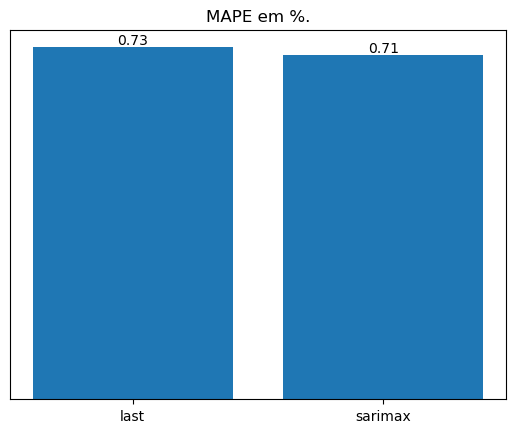

In [45]:
fig, ax = plt.subplots()
bars = ax.bar(series_mape.index, series_mape.values)
ax.bar_label(bars, fmt='%.2f')
ax.set_yticks([])
ax.set_title('MAPE em %.')
plt.show()